In [1]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import os
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dropout,
    Dense, GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

ModuleNotFoundError: No module named 'google.colab'

In [2]:
from google.colab import drive
from google.colab.patches import cv2_imshow



drive.mount('/content/drive')

# ============================================================
# 2. PARÁMETROS
# ============================================================

BASE_PATH = "/content/drive/MyDrive/VISION-4/RETO1/3scenes"

CLASSES = ["coast", "forest", "highway"]

IMG_SIZE = 128
CHANNELS = 3
TEST_SIZE = 0.25
RANDOM_STATE = 42

BATCH_SIZE = 32
EPOCHS_BASELINE = 30
EPOCHS_RESNET = 20

LEARNING_RATE_BASELINE = 1e-3
LEARNING_RATE_RESNET = 1e-4

NUM_CLASSES = len(CLASSES)

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

Mounted at /content/drive


In [3]:

# ============================================================
# 3. CARGAR IMÁGENES
# ============================================================

data = []
labels = []

for class_name in CLASSES:
    class_path = os.path.join(BASE_PATH, class_name)

    if not os.path.exists(class_path):
        raise FileNotFoundError(f"No existe la carpeta: {class_path}")

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"Clase {class_name}: {len(files)} imágenes")

    for file in files:
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        if img is None:
            print(f"No se pudo leer: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype("float32") / 255.0

        data.append(img)
        labels.append(class_name)

data = np.array(data)
labels = np.array(labels)

print("Total imágenes:", len(data))
print("Shape dataset:", data.shape)

Clase coast: 360 imágenes
Clase forest: 328 imágenes
Clase highway: 270 imágenes
Total imágenes: 958
Shape dataset: (958, 128, 128, 3)


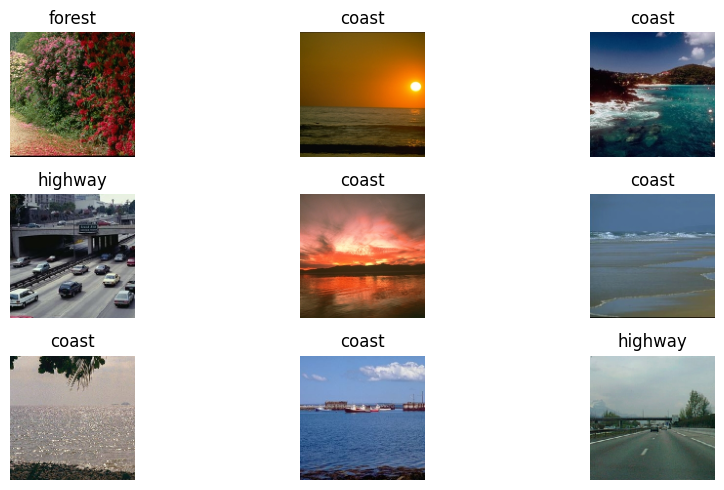

In [4]:
# ============================================================
# 4. VISUALIZAR EJEMPLOS
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(9):
    idx = random.randint(0, len(data) - 1)
    plt.subplot(3, 3, i + 1)
    plt.imshow(data[idx])
    plt.title(labels[idx])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 5. CODIFICAR ETIQUETAS
# ============================================================

lb = LabelBinarizer()
labels_encoded = lb.fit_transform(labels)

print("Clases:", lb.classes_)
print("Shape etiquetas:", labels_encoded.shape)

Clases: ['coast' 'forest' 'highway']
Shape etiquetas: (958, 3)


In [6]:
# ============================================================
# 6. DIVISIÓN TRAIN / TEST
# ============================================================

trainX, testX, trainY, testY = train_test_split(
    data,
    labels_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels_encoded
)

print("Train X:", trainX.shape)
print("Test X:", testX.shape)
print("Train Y:", trainY.shape)
print("Test Y:", testY.shape)

Train X: (718, 128, 128, 3)
Test X: (240, 128, 128, 3)
Train Y: (718, 3)
Test Y: (240, 3)


In [7]:
print("Clases detectadas:", lb.classes_)

unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

print("Train:", trainY.sum(axis=0))
print("Test:", testY.sum(axis=0))

Clases detectadas: ['coast' 'forest' 'highway']
{np.str_('coast'): np.int64(360), np.str_('forest'): np.int64(328), np.str_('highway'): np.int64(270)}
Train: [270 246 202]
Test: [90 82 68]


In [8]:
# ============================================================
# 7. CNN SECUENCIAL MEJORADA
# ============================================================

from tensorflow.keras.layers import Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Flatten

tf.keras.backend.clear_session()

baseline_model = Sequential(name="CNN_Secuencial_Reto1_Corregida")

baseline_model.add(Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))

baseline_model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
baseline_model.add(MaxPooling2D((2, 2)))

baseline_model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
baseline_model.add(MaxPooling2D((2, 2)))

baseline_model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
baseline_model.add(MaxPooling2D((2, 2)))

baseline_model.add(Conv2D(256, (3, 3), activation="relu", padding="same"))
baseline_model.add(MaxPooling2D((2, 2)))

baseline_model.add(Flatten())

baseline_model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
baseline_model.add(Dropout(0.4))

baseline_model.add(Dense(NUM_CLASSES, activation="softmax"))

baseline_model.summary()

Model: "CNN_Secuencial_Reto1_Corregida"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583,747 (17.49 MB)

 Trainable params: 4,583,747 (17.49 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ============================================================
# 8. COMPILAR CNN SECUENCIAL
# ============================================================

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_baseline = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        mode="max",
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]


In [10]:
# ============================================================
# 9. ENTRENAR CNN SECUENCIAL
# ============================================================

history_baseline = baseline_model.fit(
    trainX,
    trainY,
    validation_data=(testX, testY),
    epochs=40,
    batch_size=32,
    callbacks=callbacks_baseline,
    verbose=1
)

Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 467ms/step - accuracy: 0.5153 - loss: 1.4854 - val_accuracy: 0.5875 - val_loss: 1.2670 - learning_rate: 1.0000e-04
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6435 - loss: 1.1623 - val_accuracy: 0.8125 - val_loss: 0.9634 - learning_rate: 1.0000e-04
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7772 - loss: 0.8981 - val_accuracy: 0.8917 - val_loss: 0.7306 - learning_rate: 1.0000e-04
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8691 - loss: 0.6864 - val_accuracy: 0.8667 - val_loss: 0.6378 - learning_rate: 1.0000e-04
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8719 - loss: 0.6407 - val_accuracy: 0.9125 - val_loss: 0.5657 - learning_rate: 1.0000e-04
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8886 - loss: 0.5651 - val_accuracy: 0.9083 - val_loss: 0.5236 - learning_rate: 1.0000e-04
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.909

In [11]:
# ============================================================
# 10. FUNCIONES DE EVALUACIÓN
# ============================================================

def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, testX, testY, class_names, title):
    predictions = model.predict(testX, batch_size=BATCH_SIZE)

    y_true = testY.argmax(axis=1)
    y_pred = predictions.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)

    print(f"\nResultados del modelo: {title}")
    print(f"Accuracy: {acc:.4f}")
    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Matriz de confusión - {title}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.show()

    return acc, predictions

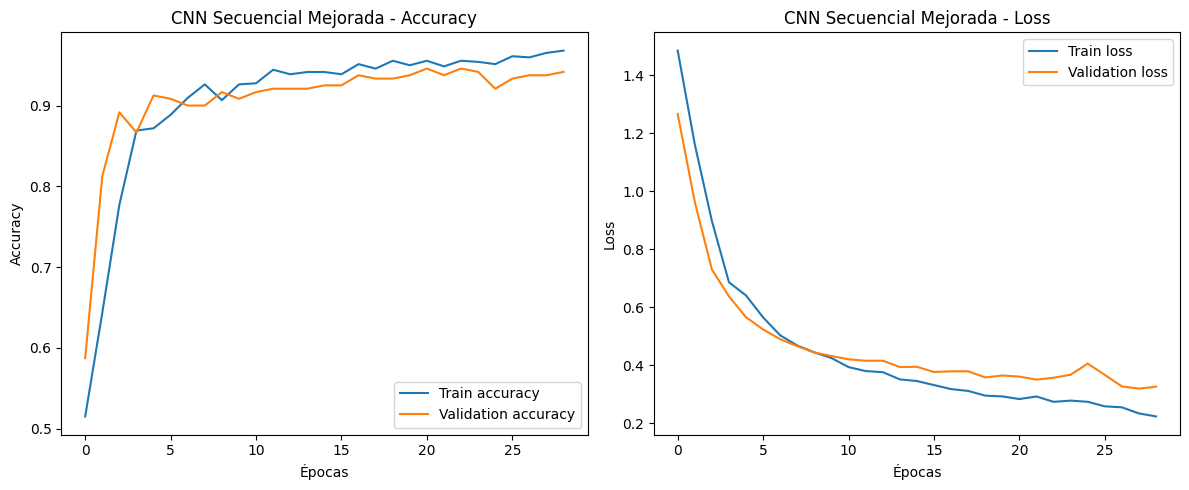

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step

Resultados del modelo: CNN Secuencial Mejorada
Accuracy: 0.9458

Reporte de clasificación:
              precision    recall  f1-score   support

       coast       0.91      0.94      0.93        90
      forest       0.99      0.99      0.99        82
     highway       0.94      0.90      0.92        68

    accuracy                           0.95       240
   macro avg       0.95      0.94      0.94       240
weighted avg       0.95      0.95      0.95       240



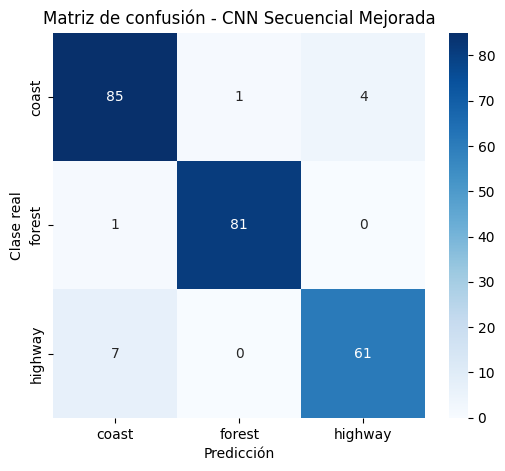

In [12]:
# ============================================================
# 11. EVALUAR CNN SECUENCIAL
# ============================================================

plot_training_history(history_baseline, "CNN Secuencial Mejorada")

acc_baseline, predictions_baseline = evaluate_model(
    baseline_model,
    testX,
    testY,
    lb.classes_,
    "CNN Secuencial Mejorada"
)

In [13]:
# ============================================================
# 12. PREPARAR DATOS PARA RESNET
# ============================================================

trainX_resnet = preprocess_input((trainX * 255).astype("float32"))
testX_resnet = preprocess_input((testX * 255).astype("float32"))

In [ ]:
# ============================================================
# 13. MODELO RESNET50 NO SECUENCIAL
# ============================================================

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)
)

base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output, name="ResNet50_Transfer_Learning")

resnet_model.summary()

Model: "ResNet50_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
# ============================================================
# 13. MODELO RESNET50 NO SECUENCIAL
# ============================================================

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)
)

base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output, name="ResNet50_Transfer_Learning")

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
# ============================================================
# 14. COMPILAR RESNET50
# ============================================================

optimizer_resnet = Adam(learning_rate=LEARNING_RATE_RESNET)

resnet_model.compile(
    optimizer=optimizer_resnet,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_resnet = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

In [16]:
# ============================================================
# 15. ENTRENAR RESNET50
# ============================================================

history_resnet = resnet_model.fit(
    trainX_resnet,
    trainY,
    validation_data=(testX_resnet, testY),
    epochs=EPOCHS_RESNET,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_resnet,
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 617ms/step - accuracy: 0.5808 - loss: 1.1846 - val_accuracy: 0.9208 - val_loss: 0.2377 - learning_rate: 1.0000e-04
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8914 - loss: 0.2904 - val_accuracy: 0.9667 - val_loss: 0.1076 - learning_rate: 1.0000e-04
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9345 - loss: 0.1824 - val_accuracy: 0.9833 - val_loss: 0.0790 - learning_rate: 1.0000e-04
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9680 - loss: 0.1245 - val_accuracy: 0.9833 - val_loss: 0.0675 - learning_rate: 1.0000e-04
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9708 - loss: 0.1073 - val_accuracy: 0.9792 - val_loss: 0.0558 - learning_rate: 1.0000e-04
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9805 - loss: 0.0716 - val_accuracy: 0.9792 - val_loss: 0.0499 - learning_rate: 1.0000e-04
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.980

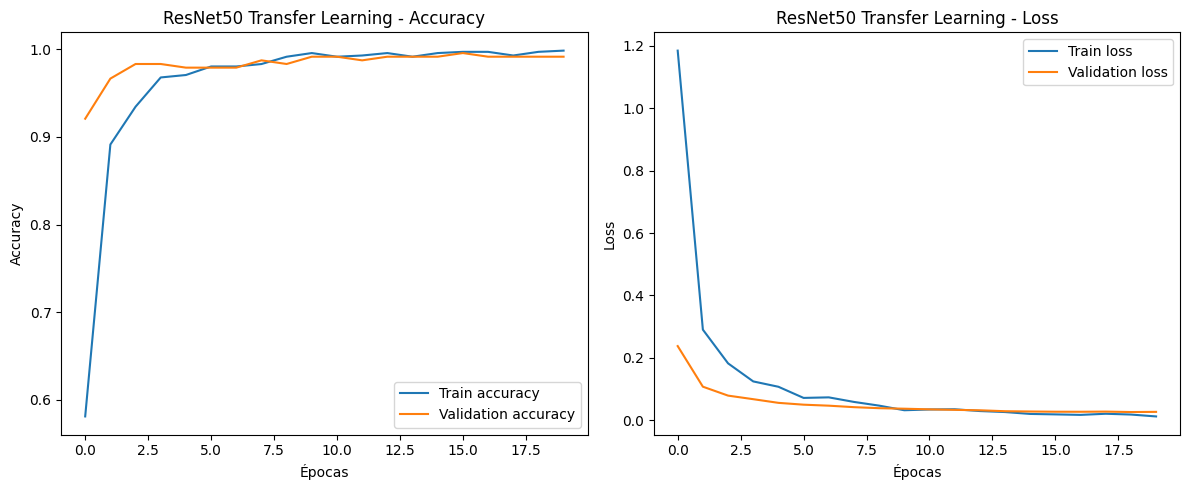

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 645ms/step

Resultados del modelo: ResNet50 Transfer Learning
Accuracy: 0.9917

Reporte de clasificación:
              precision    recall  f1-score   support

       coast       0.98      1.00      0.99        90
      forest       1.00      1.00      1.00        82
     highway       1.00      0.97      0.99        68

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



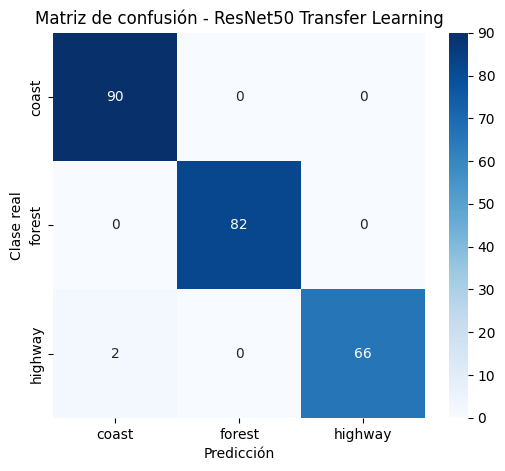

In [17]:
# ============================================================
# 16. EVALUAR RESNET50
# ============================================================

plot_training_history(history_resnet, "ResNet50 Transfer Learning")

acc_resnet, predictions_resnet = evaluate_model(
    resnet_model,
    testX_resnet,
    testY,
    lb.classes_,
    "ResNet50 Transfer Learning"
)

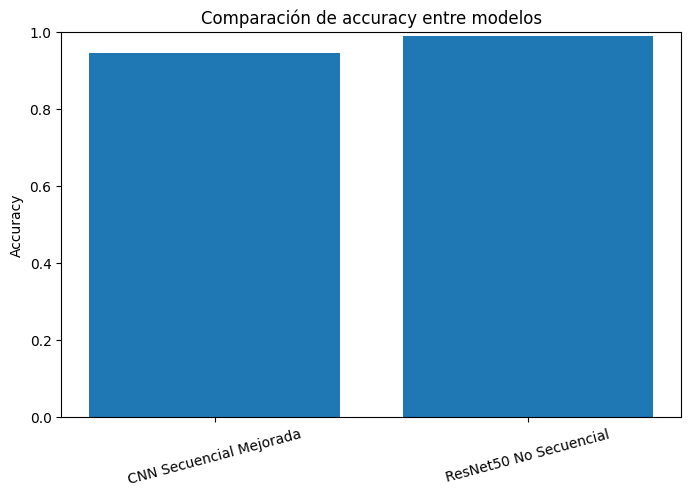

CNN Secuencial Mejorada: 0.9458
ResNet50 No Secuencial: 0.9917


In [18]:
# ============================================================
# 17. COMPARACIÓN FINAL
# ============================================================

results = {
    "CNN Secuencial Mejorada": acc_baseline,
    "ResNet50 No Secuencial": acc_resnet
}

plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.title("Comparación de accuracy entre modelos")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


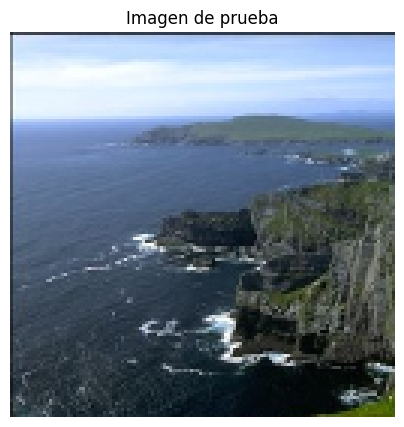

Clase real: coast
Predicción CNN secuencial: coast
Predicción ResNet50: coast


In [19]:
# ============================================================
# 18. PRUEBA CON IMAGEN ALEATORIA
# ============================================================

rand_pos = random.randint(0, len(testX) - 1)

img = testX[rand_pos]
true_class = lb.classes_[np.argmax(testY[rand_pos])]

pred_baseline = baseline_model.predict(np.expand_dims(img, axis=0))
pred_class_baseline = lb.classes_[np.argmax(pred_baseline)]

img_resnet = preprocess_input(np.expand_dims((img * 255).astype("float32"), axis=0))
pred_resnet = resnet_model.predict(img_resnet)
pred_class_resnet = lb.classes_[np.argmax(pred_resnet)]

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Imagen de prueba")
plt.show()

print("Clase real:", true_class)
print("Predicción CNN secuencial:", pred_class_baseline)
print("Predicción ResNet50:", pred_class_resnet)

In [20]:
import os
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

EVIDENCE_DIR = "/content/drive/MyDrive/VISION-4/RETO1/evidencias_reto1"
os.makedirs(EVIDENCE_DIR, exist_ok=True)

# Guardar modelos
baseline_model.save(os.path.join(EVIDENCE_DIR, "cnn_secuencial_mejorada.keras"))
resnet_model.save(os.path.join(EVIDENCE_DIR, "resnet50_transfer_learning.keras"))


# Guardar reportes
def save_evidence(model, testX_data, testY_data, model_name):
    predictions = model.predict(testX_data)
    y_true = testY_data.argmax(axis=1)
    y_pred = predictions.argmax(axis=1)

    report = classification_report(
        y_true,
        y_pred,
        target_names=lb.classes_,
        output_dict=True,
        zero_division=0
    )

    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(os.path.join(EVIDENCE_DIR, f"reporte_{model_name}.csv"))

    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=lb.classes_, columns=lb.classes_)
    df_cm.to_csv(os.path.join(EVIDENCE_DIR, f"matriz_confusion_{model_name}.csv"))


save_evidence(
    baseline_model,
    testX,
    testY,
    "cnn_secuencial"
)

save_evidence(
    resnet_model,
    testX_resnet,
    testY,
    "resnet50"
)

print("Evidencias guardadas en:", EVIDENCE_DIR)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Evidencias guardadas en: /content/drive/MyDrive/VISION-4/RETO1/evidencias_reto1
